<a href="https://colab.research.google.com/github/Shovan61/Research-Seminar-Filter-Preference-Instagram/blob/main/instagram_filter_preference_research_seminar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

In [5]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
DATASET_PATH = '/content/drive/MyDrive/data_Instagram'
CSV_FILE = 'prefs.csv'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 8

In [7]:
# Create output directory for saving plots
os.makedirs('/content/results', exist_ok=True)

In [8]:
# ----------------------------- 3. LOAD DATA ---------------------------------
print("="*60)
print("STEP 1: Loading data")
print("="*60)

STEP 1: Loading data


In [9]:
csv_path = os.path.join(DATASET_PATH, CSV_FILE)

In [10]:
df = pd.read_csv(csv_path)
df['full_path'] = DATASET_PATH + '/' + df['img']

In [11]:
print(f"Total images loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"First 5 rows:\n{df.head()}")

Total images loaded: 108
Columns: ['Unnamed: 0', 'img', 'pid', 'filter', 'full_path']
First 5 rows:
   Unnamed: 0         img  pid    filter  \
0           0  ai/p01.png  p01   mayfair   
1           1  ai/p02.png  p02  brooklyn   
2           2  ai/p03.png  p03       org   
3           3  ai/p04.png  p04  perpetua   
4           4  ai/p05.png  p05   inkwell   

                                          full_path  
0  /content/drive/MyDrive/data_Instagram/ai/p01.png  
1  /content/drive/MyDrive/data_Instagram/ai/p02.png  
2  /content/drive/MyDrive/data_Instagram/ai/p03.png  
3  /content/drive/MyDrive/data_Instagram/ai/p04.png  
4  /content/drive/MyDrive/data_Instagram/ai/p05.png  


In [12]:
# Count images by type
ai_count = df['img'].str.contains('ai/').sum()
real_count = df['img'].str.contains('real/').sum()
print(f"\n📊 Image distribution: AI: {ai_count}, Real: {real_count}")


📊 Image distribution: AI: 54, Real: 54



STEP 2: Visualizing sample images from dataset


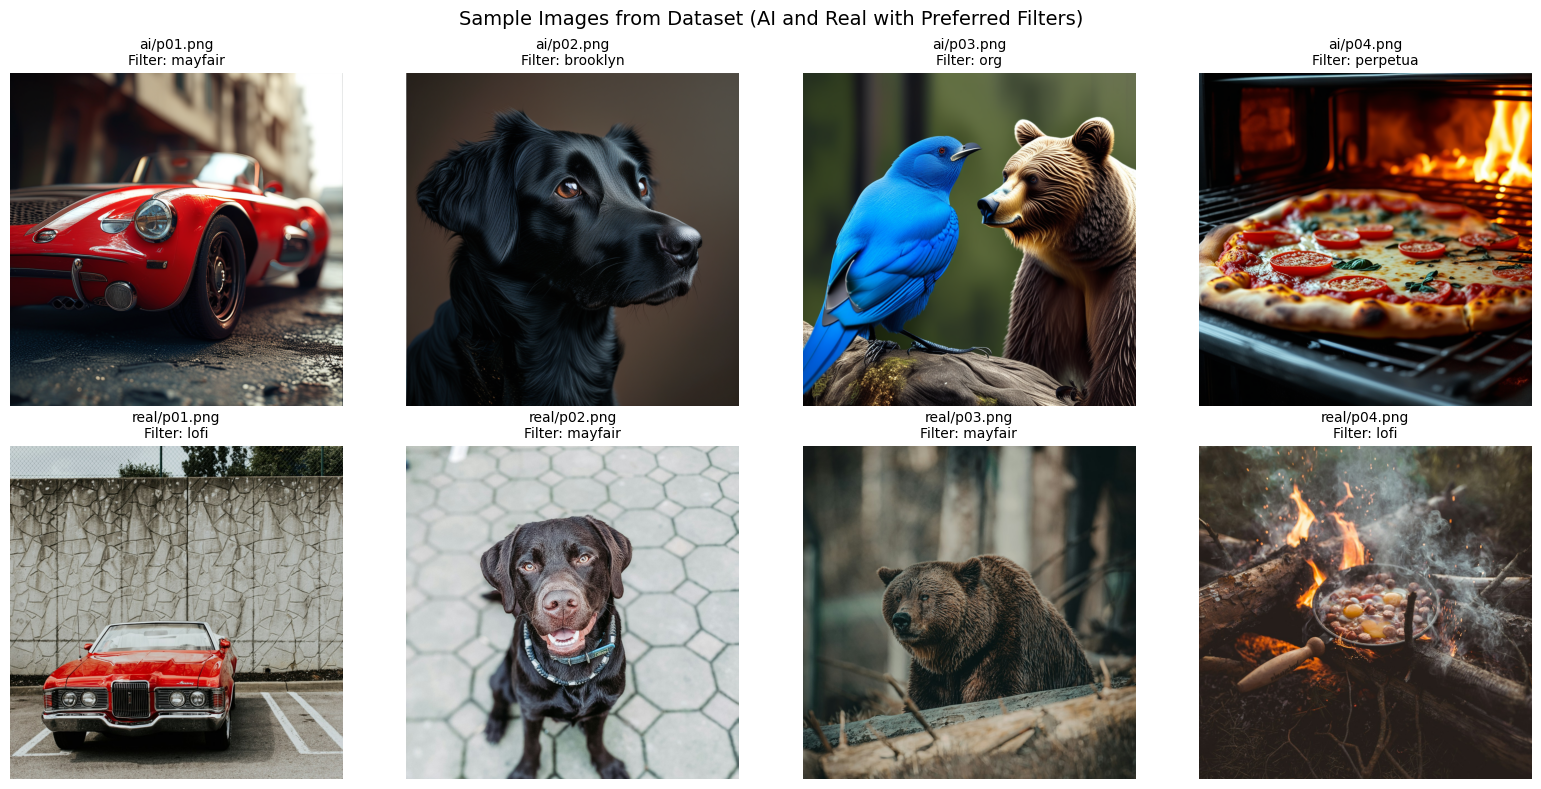

✅ Sample images visualization saved to /content/results/sample_images.png


In [13]:
# ----------------------------- 4. VISUALIZE SAMPLE IMAGES -------------------
print("\n" + "="*60)
print("STEP 2: Visualizing sample images from dataset")
print("="*60)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

sample_indices = [0, 1, 2, 3, 54, 55, 56, 57]  # AI and Real samples
for idx, ax in enumerate(axes):
    row = df.iloc[sample_indices[idx]]
    img_path = row['full_path']
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{row['img']}\nFilter: {row['filter']}", fontsize=10)
    else:
        ax.set_title(f"Image not found: {row['img']}")
    ax.axis('off')

plt.suptitle('Sample Images from Dataset (AI and Real with Preferred Filters)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images visualization saved to /content/results/sample_images.png")


STEP 3: Handling rare filter classes
Original class distribution:
 filter
clarendon    20
lofi         15
brooklyn     12
org          11
mayfair      10
kelvin        6
perpetua      5
gingham       5
slumber       5
inkwell       4
earlybird     4
lark          2
rise          2
hudson        2
brannan       1
valencia      1
xpro2         1
walden        1
aden          1
Name: count, dtype: int64


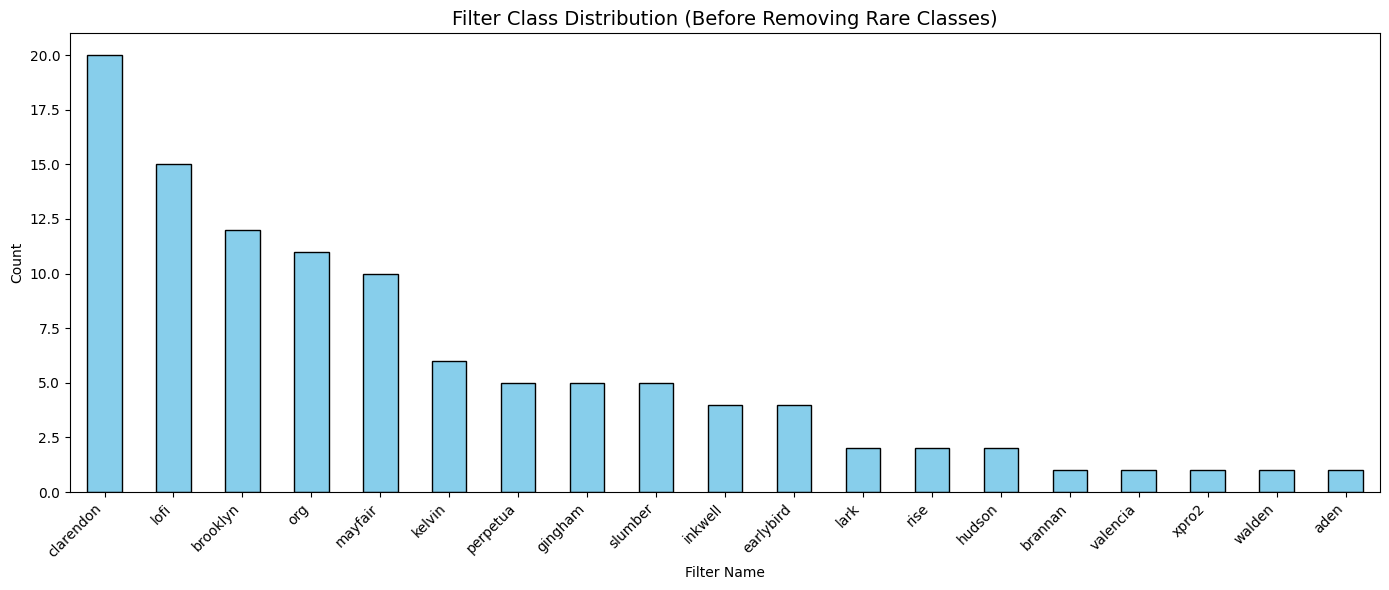


⚠️ Filters with <2 samples: ['brannan', 'valencia', 'xpro2', 'walden', 'aden']
Removed 5 rare filters
Remaining samples: 103


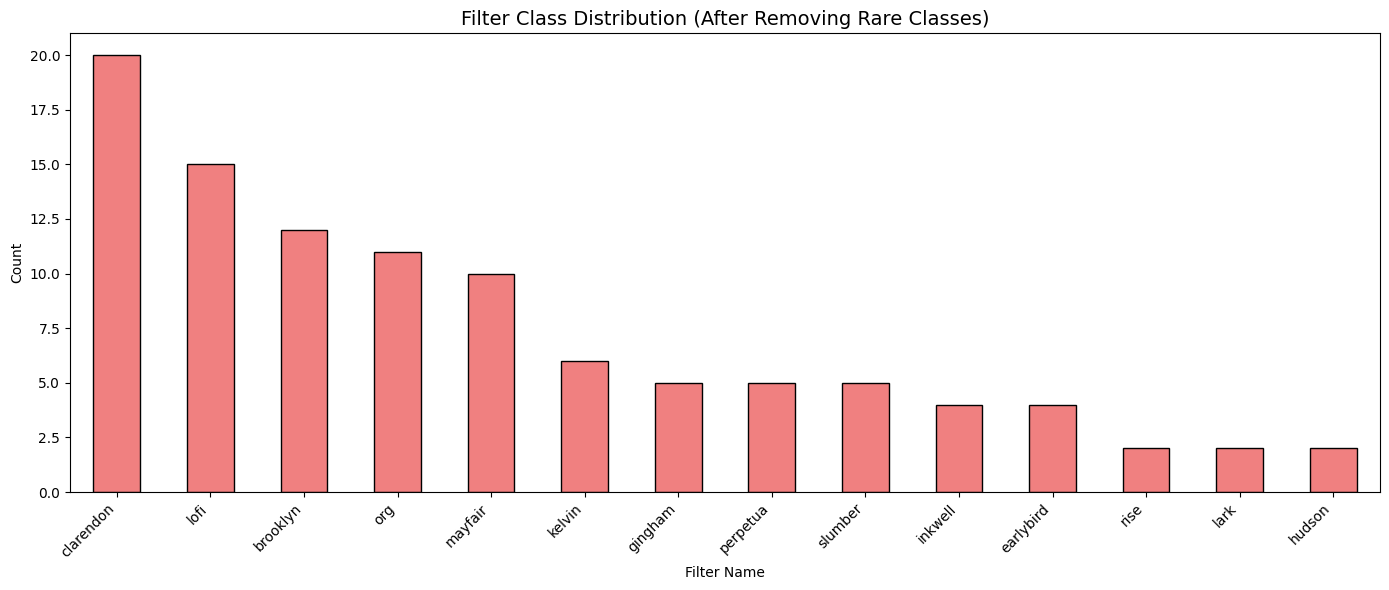

In [14]:
# ----------------------------- 5. HANDLE RARE CLASSES -----------------------
print("\n" + "="*60)
print("STEP 3: Handling rare filter classes")
print("="*60)

class_counts = df['filter'].value_counts()
print("Original class distribution:\n", class_counts)

# Plot class distribution
plt.figure(figsize=(14, 6))
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Filter Class Distribution (Before Removing Rare Classes)', fontsize=14)
plt.xlabel('Filter Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/results/class_distribution_before.png', dpi=150, bbox_inches='tight')
plt.show()

# Find filters with less than 2 samples
rare_filters = class_counts[class_counts < 2].index.tolist()
print(f"\n⚠️ Filters with <2 samples: {rare_filters}")

# Remove rare filters
if rare_filters:
    df = df[~df['filter'].isin(rare_filters)].copy()
    print(f"Removed {len(rare_filters)} rare filters")
    print(f"Remaining samples: {len(df)}")

# Plot updated class distribution
plt.figure(figsize=(14, 6))
df['filter'].value_counts().plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Filter Class Distribution (After Removing Rare Classes)', fontsize=14)
plt.xlabel('Filter Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/results/class_distribution_after.png', dpi=150, bbox_inches='tight')
plt.show()